In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Load Data - Using the path from your screenshot
file_path = r'C:/Users/hp/archive/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv'
df = pd.read_csv(file_path)

# Data Cleaning
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# 3-Level Categorization logic
def categorize_risk(label):
    label = str(label).strip()
    if 'BENIGN' in label: return 0  # Low
    elif 'PortScan' in label: return 1  # Medium
    else: return 2  # High

df['Risk_Level'] = df[' Label'].apply(categorize_risk)

# Prepare Features
X = df.select_dtypes(include=[np.number]).drop(['Risk_Level'], axis=1)
y = df['Risk_Level']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluation - Dynamically detect present classes to avoid ValueError
y_pred_rf = rf_model.predict(X_test)
present_classes = [ ['Low', 'Medium', 'High'][i] for i in np.unique(y_test) ]

print("--- Random Forest Detailed Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf, target_names=present_classes))

--- Random Forest Detailed Results ---
Accuracy: 0.9999
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00     25459
      Medium       1.00      1.00      1.00     31761

    accuracy                           1.00     57220
   macro avg       1.00      1.00      1.00     57220
weighted avg       1.00      1.00      1.00     57220



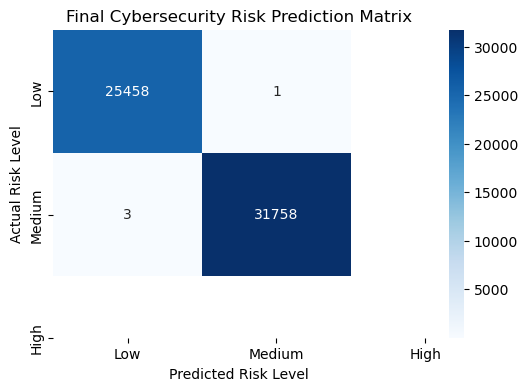

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Use the predictions from your trained Random Forest model
# Note: y_test and y_pred_rf must be defined from your previous run
cm = confusion_matrix(y_test, y_pred_rf)

# Define display labels based on the unique values present in y_test
labels = ['Low', 'Medium', 'High']

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)

plt.title('Final Cybersecurity Risk Prediction Matrix')
plt.xlabel('Predicted Risk Level')
plt.ylabel('Actual Risk Level')
plt.show()

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Initialize the Decision Tree with Gini impurity criterion
# We set a max_depth to prevent the tree from becoming too complex (overfitting)
dt_model = DecisionTreeClassifier(criterion='gini', max_depth=15, random_state=42)

# Training the model
dt_model.fit(X_train, y_train)

# Making Predictions
y_pred_dt = dt_model.predict(X_test)

# Evaluation
print("--- Decision Tree Detailed Results ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_dt):.4f}")

# Dynamically identifying labels present in the test set to avoid report errors
labels_present = [ ['Low', 'Medium', 'High'][i] for i in np.unique(y_test) ]
print(classification_report(y_test, y_pred_dt, target_names=labels_present))

--- Decision Tree Detailed Results ---
Accuracy Score: 0.9998
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00     25459
      Medium       1.00      1.00      1.00     31761

    accuracy                           1.00     57220
   macro avg       1.00      1.00      1.00     57220
weighted avg       1.00      1.00      1.00     57220



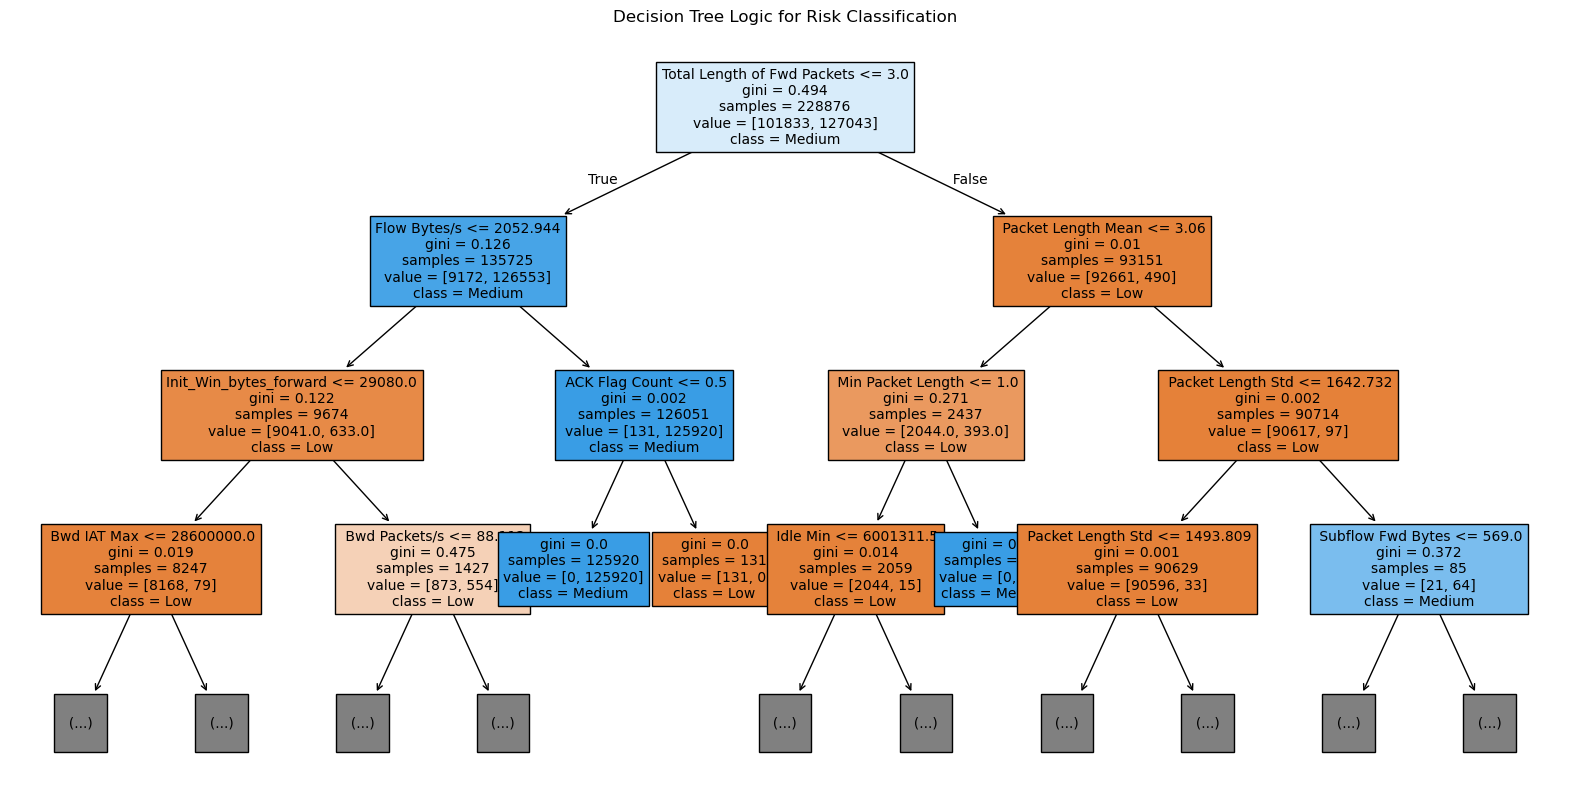

In [16]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(dt_model, 
          feature_names=X.columns, 
          class_names=['Low', 'Medium', 'High'], 
          filled=True, 
          max_depth=3, # Limit depth so the image is readable
          fontsize=10)
plt.title("Decision Tree Logic for Risk Classification")
plt.show()

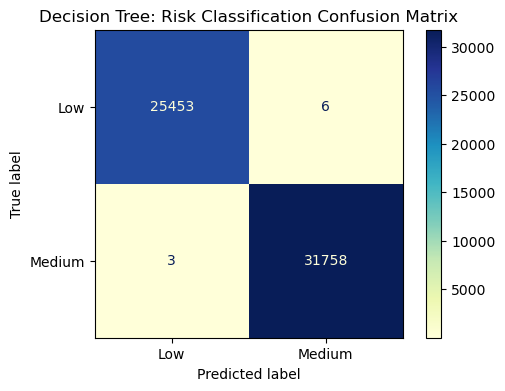

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# 1. Generate predictions if not already done
y_pred_dt = dt_model.predict(X_test)

# 2. Identify which classes actually exist in y_test to prevent ValueErrors
unique_classes = np.unique(np.concatenate([y_test, y_pred_dt]))
all_labels = ['Low', 'Medium', 'High']
present_labels = [all_labels[i] for i in unique_classes]

# 3. Create and Plot the Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=present_labels)

fig, ax = plt.subplots(figsize=(6, 4))
disp.plot(cmap='YlGnBu', ax=ax)
plt.title('Decision Tree: Risk Classification Confusion Matrix')
plt.show()

In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# 1. Feature Scaling (Required for KNN to function correctly)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Initialize and Train KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# 3. Generate Predictions
y_pred_knn = knn_model.predict(X_test_scaled)

# 4. Identify labels present to avoid ValueErrors
unique_indices = np.unique(np.concatenate([y_test, y_pred_knn]))
all_risk_labels = ['Low', 'Medium', 'High']
labels_present = [all_risk_labels[i] for i in unique_indices]

# 5. Print the Report for your Documentation
print("--- K-Nearest Neighbors (KNN) Classification Report ---")
print(classification_report(y_test, y_pred_knn, target_names=labels_present))

--- K-Nearest Neighbors (KNN) Classification Report ---
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00     25459
      Medium       1.00      1.00      1.00     31761

    accuracy                           1.00     57220
   macro avg       1.00      1.00      1.00     57220
weighted avg       1.00      1.00      1.00     57220



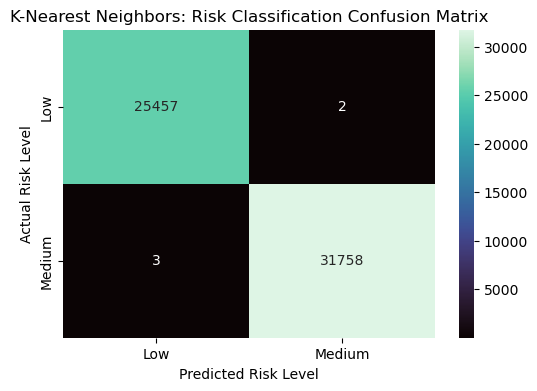

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generate the Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

# 2. Match labels to the data present in the results
unique_indices = np.unique(np.concatenate([y_test, y_pred_knn]))
all_labels = ['Low', 'Medium', 'High']
labels_present = [all_labels[i] for i in unique_indices]

# 3. Plotting
plt.figure(figsize=(6, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='mako', 
            xticklabels=labels_present, yticklabels=labels_present)

plt.title('K-Nearest Neighbors: Risk Classification Confusion Matrix')
plt.xlabel('Predicted Risk Level')
plt.ylabel('Actual Risk Level')
plt.show()